In [11]:
!pip install --upgrade matplotlib numpy pillow

Defaulting to user installation because normal site-packages is not writeable


動画を生成しています...
バスの移動アニメーション動画 'bus_animation.mp4' が作成されました。


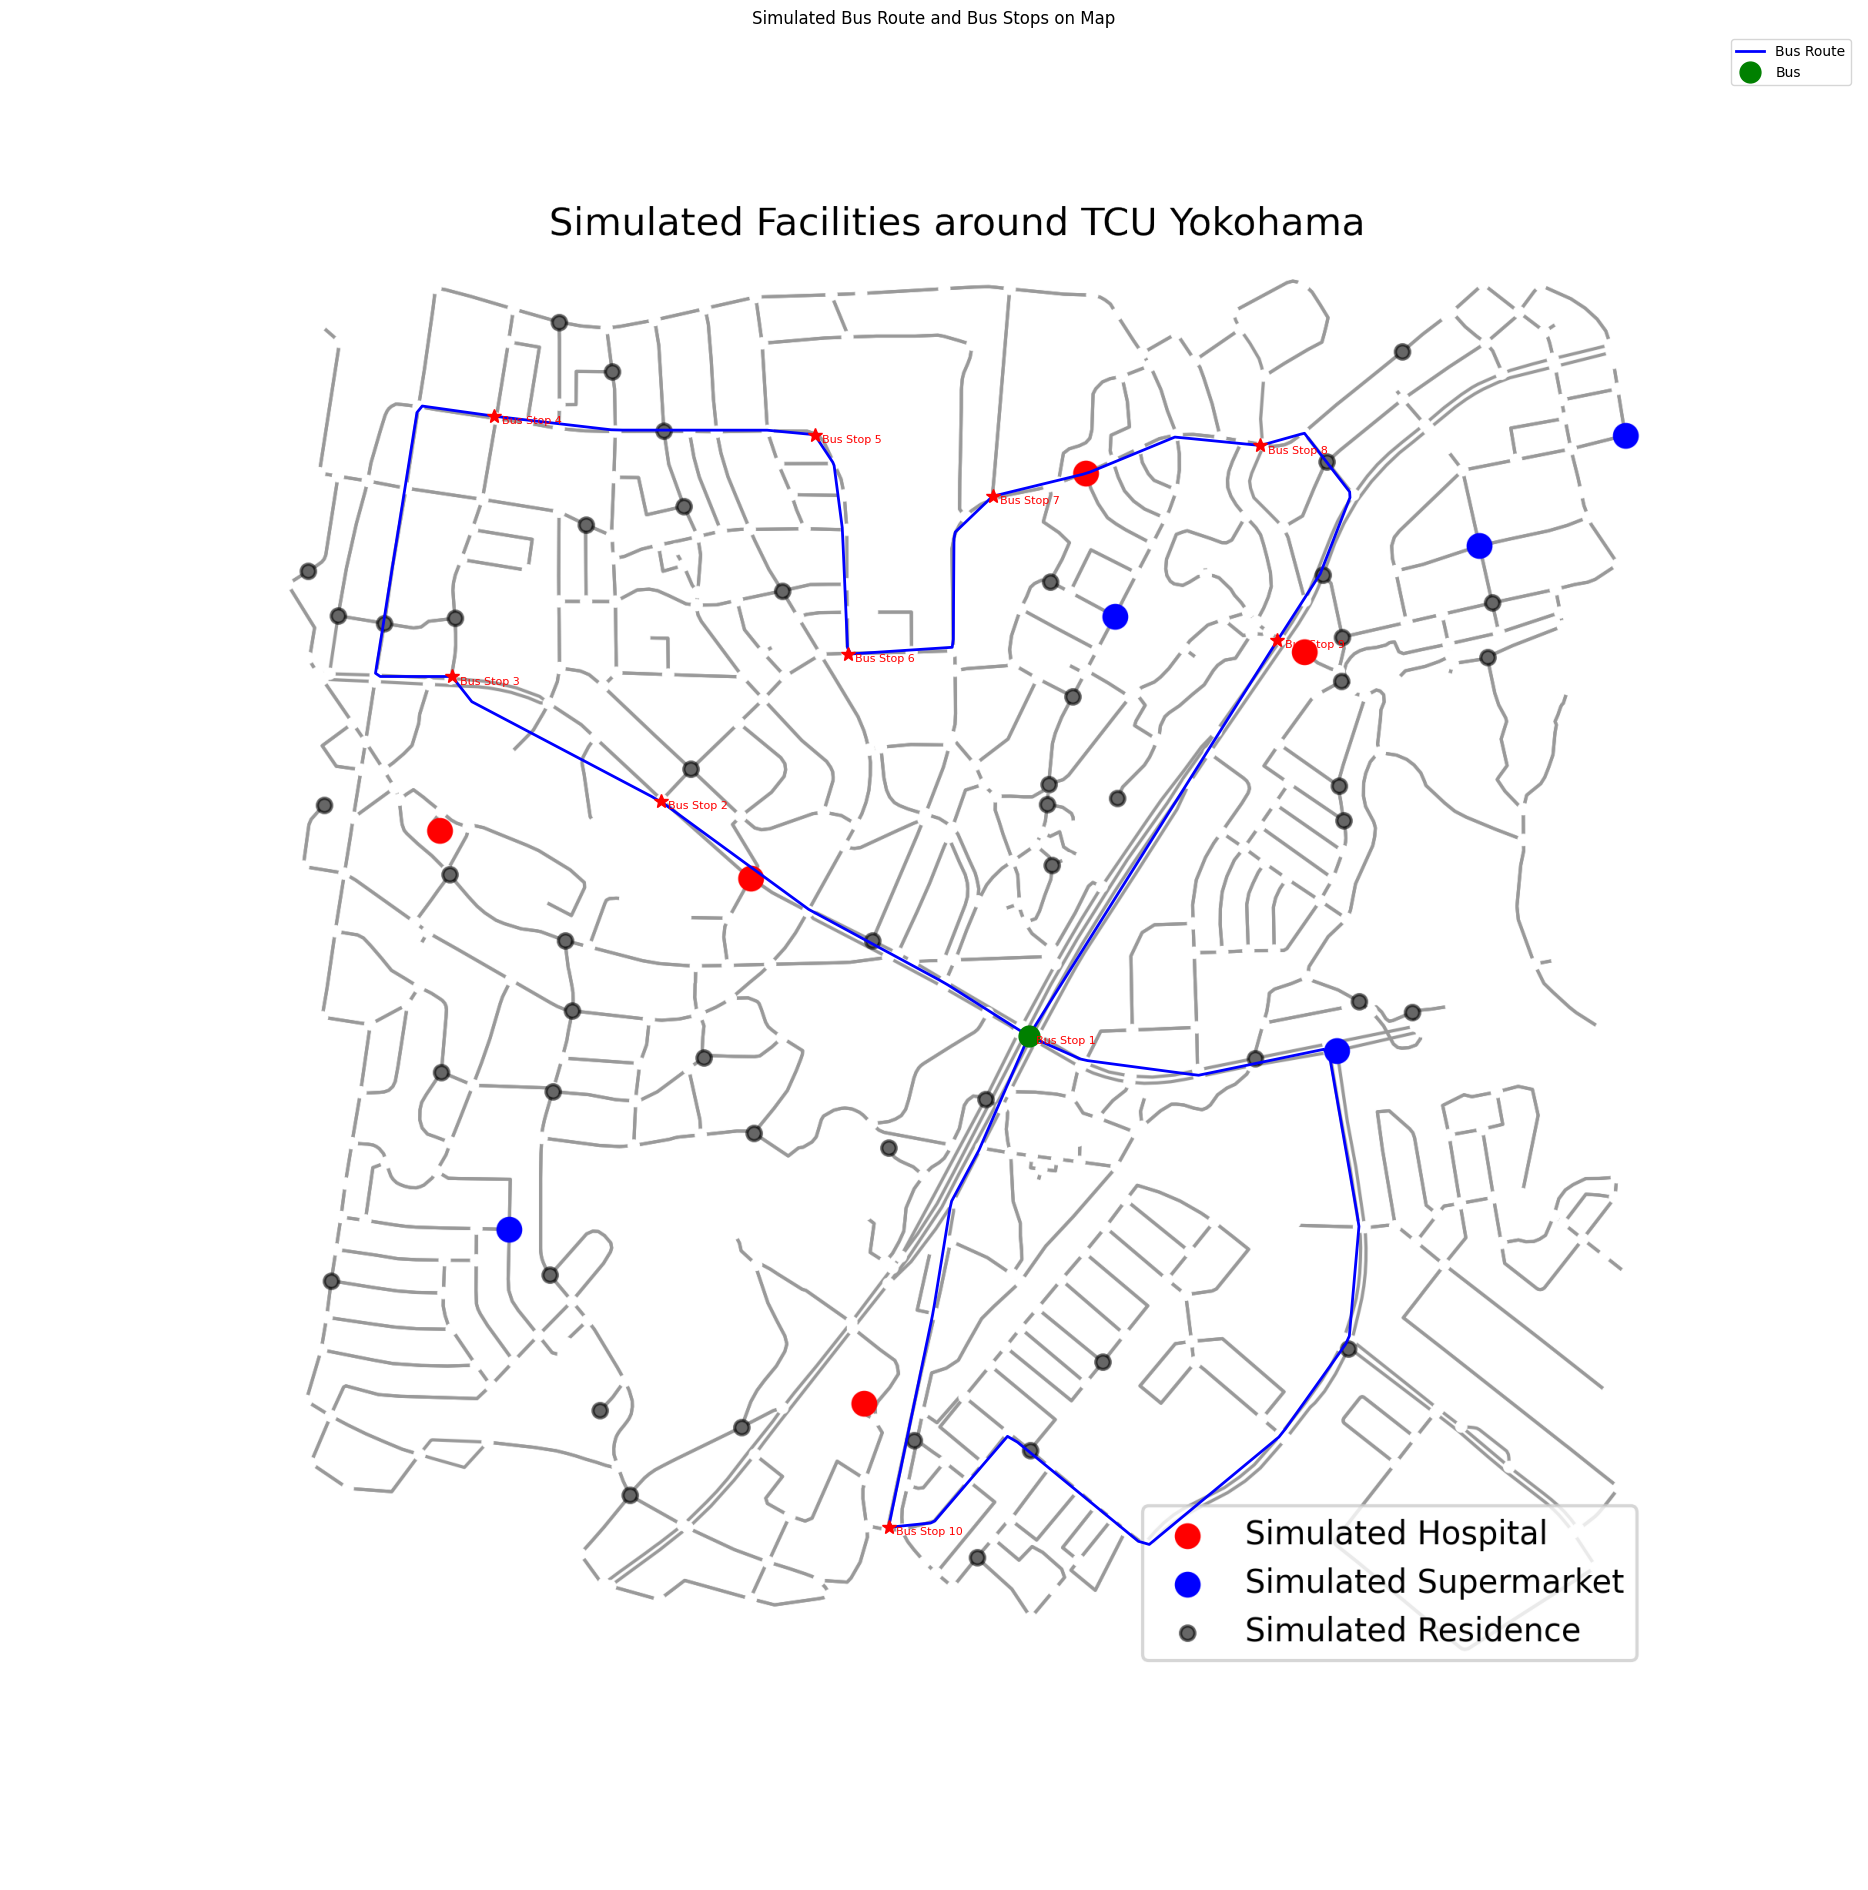

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.animation as animation

# 1. 地図画像を読み込む
try:
    map_image = Image.open("tcu_map_simulated_facilities_all.png")
except FileNotFoundError:
    print("エラー: 'tcu_map_simulated_facilities_named.png' が見つかりません。")
    print("地図画像ファイルをコードと同じディレクトリに配置してください。")
    exit()

width, height = map_image.size

# 2. バス経路の座標を定義
route_points = np.array([
    [1323, 1304],
    [1214, 1235],
    [1038, 1140],
    [845, 999],
    [600, 870],
    [574, 837],
    [474, 837],
    [530, 485],
    [629, 499],
    [784, 517],
    [982, 517],
    [1045, 523],
    [1070, 561],
    [1081, 645],
    [1088, 808],
    [1225, 799],
    [1226, 651],
    [1276, 603],
    [1399, 573],
    [1513, 526],
    [1624, 537],
    [1681, 521],
    [1742, 600],
    [1702, 703],
    [1646, 790],
    [1528, 977],
    [1323, 1304],
    [1259, 1451],
    [1222, 1520],
    [1199, 1662],
    [1141, 1942],
    [1199, 1936],
    [1297, 1822],
    [1475, 1968],
    [1650, 1823],
    [1739, 1698],
    [1752, 1550],
    [1712, 1320],
    [1543, 1355],
    [1393, 1335],
    [1323, 1304],
])

# 3. 経路を滑らかにする
num_points = 500
t = np.linspace(0, 1, len(route_points))
t_smooth = np.linspace(0, 1, num_points)

route_x_interp = np.interp(t_smooth, t, route_points[:, 0])
route_y_interp = np.interp(t_smooth, t, route_points[:, 1])

# 4. 10個のバス停の座標を定義
bus_stops = {
    'Bus Stop 1': [1323, 1304],
    'Bus Stop 2': [845, 999],
    'Bus Stop 3': [574, 837],
    'Bus Stop 4': [629, 499],
    'Bus Stop 5': [1045, 523],
    'Bus Stop 6': [1088, 808],
    'Bus Stop 7': [1276, 603],
    'Bus Stop 8': [1624, 537],
    'Bus Stop 9': [1646, 790],
    'Bus Stop 10': [1141, 1942]
}

# 5. アニメーションの初期設定
fig, ax = plt.subplots(figsize=(width/100, height/100), dpi=100)
ax.set_title("Simulated Bus Route and Bus Stops on Map")
ax.axis('off')

# 各フレームを生成する関数
def update(frame):
    ax.clear()
    ax.imshow(map_image, extent=[0, width, height, 0])
    
    # バス経路を描画
    ax.plot(route_x_interp, route_y_interp, color='blue', linestyle='-', linewidth=2, label='Bus Route')

    # バス停をプロット
    for name, coords in bus_stops.items():
        ax.plot(coords[0], coords[1], 'r*', markersize=10)
        ax.text(coords[0] + 10, coords[1] + 10, name, color='red', fontsize=8)

    # 現在のバスの位置を計算
    # フレーム数に応じて経路上の位置を決定
    idx = int((frame / (num_frames - 1)) * (num_points - 1))
    current_x = route_x_interp[idx]
    current_y = route_y_interp[idx]
    
    # バスの現在位置をプロット（緑色の丸）
    ax.plot(current_x, current_y, 'go', markersize=15, label='Bus')

    ax.set_title("Simulated Bus Route and Bus Stops on Map")
    ax.axis('off')
    ax.legend(loc='upper right')

# アニメーションの作成と保存
# フレーム数を200に設定
num_frames = 200
# FuncAnimationを使ってアニメーションオブジェクトを作成
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=50) # 200フレーム、各フレーム50ミリ秒間隔

print("動画を生成しています...")
# MP4形式で動画を保存。writer='ffmpeg'はFFmpegを使用することを指定
ani.save('bus_animation.gif', writer='pillow', fps=20) 

print("バスの移動アニメーション動画 'bus_animation.mp4' が作成されました。")